# Section 7.4: Generative AI & Agentic Experimentation

This notebook implements an AI-powered dynamic pricing advisor combining XGBoost predictions with Groq LLM recommendations, and presents the Responsible AI Framework and MLOps workflow.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from groq import Groq
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load environment variables
load_dotenv('../.env')
groq_api_key = os.getenv('GROQ_API_KEY')
groq_client = Groq(api_key=groq_api_key) if groq_api_key else None

print('Connecting to DuckDB ...')
con = duckdb.connect('../data/warehouse.duckdb', read_only=True)

print('Loading model artefacts ...')
model = joblib.load('../models/xgboost_model.joblib')
meta = joblib.load('../models/model_meta.joblib')
explainer = joblib.load('../models/shap_explainer.joblib')

print(f"Loaded XGBoost model: {type(model).__name__}")
print(f"Expected features: {len(meta['feature_cols'])}")
if groq_client:
    print("Groq client initialized successfully.")
else:
    print("WARNING: GROQ_API_KEY not found in .env")

Connecting to DuckDB ...
Loading model artefacts ...
Loaded XGBoost model: XGBRegressor
Expected features: 27
Groq client initialized successfully.


## 7.4.1 AI-Powered Dynamic Pricing Advisor

In [2]:
def get_listing_features(listing_id, con, meta):
    """
    Fetch raw data from DuckDB for a specific listing and process it
    into a feature vector matching the XGBoost training schema.
    """
    query = f"""
        SELECT f.listing_id, f.price,
               l.room_type, l.accommodates, l.bathrooms, l.bedrooms, l.beds,
               l.neighbourhood_name, n.neighbourhood_group,
               h.host_is_superhost, h.host_listings_count, h.hosts_time_as_host_years,
               f.number_of_reviews, f.review_scores_rating,
               f.review_scores_cleanliness, f.review_scores_location,
               f.review_scores_value, f.availability_365,
               f.minimum_nights, f.estimated_occupancy_l365d,
               v.demand_segment
        FROM fact_listing_performance f
        JOIN dim_listing l ON f.listing_id = l.listing_id
        JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
        JOIN dim_host h ON l.host_id = h.host_id
        JOIN v_listing_demand v ON f.listing_id = v.listing_id
        WHERE f.listing_id = {listing_id}
    """
    raw_df = con.execute(query).df()
    if raw_df.empty:
        return None, None
    
    df = raw_df.copy()
    raw_dict = df.iloc[0].to_dict()
    
    # Feature Engineering (mirroring training)
    df['is_superhost'] = (df['host_is_superhost'] == 't').astype(int)
    df['has_rating'] = df['review_scores_rating'].notna().astype(int)
    
    for col in ['review_scores_rating', 'review_scores_cleanliness',
                'review_scores_location', 'review_scores_value']:
        df[col] = df[col].fillna(0)
        
    # Imputation
    for col, med in meta['medians'].items():
        if col in df.columns:
            df[col] = df[col].fillna(med)
            
    df['beds_per_person'] = df['beds'] / df['accommodates'].clip(lower=1)
    df['room_type_enc'] = df['room_type'].map(meta['room_type_enc'])
    
    # Neighbourhood dummies
    for col in meta['ng_dummy_cols']:
        df[col] = 0
    ng_col = f"ng_{raw_dict['neighbourhood_group']}"
    if ng_col in df.columns:
        df[ng_col] = 1
        
    X = df[meta['feature_cols']].astype(float)
    return raw_dict, X

In [3]:
def predict_price(listing_id):
    """Predict the fair price for a listing and gather market context."""
    raw_dict, X = get_listing_features(listing_id, con, meta)
    if raw_dict is None:
        return None
        
    # Prediction
    pred_log = model.predict(X)[0]
    pred_price = np.expm1(pred_log)
    
    # Market context
    ng = raw_dict['neighbourhood_group']
    rt = raw_dict['room_type']
    
    med_query = f"""
        SELECT 
            percentile_cont(0.5) WITHIN GROUP (ORDER BY price) AS median_price
        FROM stg_listings
        WHERE neighbourhood_group_cleansed = '{ng.replace("'", "''")}'
          AND room_type = '{rt}'
          AND price > 0
    """
    ng_rt_median = con.execute(med_query).fetchone()[0]
    
    rank_query = f"""
        SELECT 
            count(*) * 100.0 / (SELECT count(*) FROM stg_listings 
                                WHERE neighbourhood_group_cleansed = '{ng.replace("'", "''")}' 
                                AND room_type = '{rt}' AND price > 0) AS percentile
        FROM stg_listings
        WHERE neighbourhood_group_cleansed = '{ng.replace("'", "''")}'
          AND room_type = '{rt}'
          AND price <= {pred_price}
          AND price > 0
    """
    percentile_rank = con.execute(rank_query).fetchone()[0]
    
    return {
        'listing_id': listing_id,
        'current_price': raw_dict['price'],
        'predicted_price': pred_price,
        'neighbourhood': ng,
        'room_type': rt,
        'accommodates': raw_dict['accommodates'],
        'neighbourhood_median': ng_rt_median,
        'percentile_rank': percentile_rank,
        'raw_dict': raw_dict,
        'X': X
    }

In [4]:
def generate_pricing_recommendation(price_info):
    """Generate an AI recommendation using Groq and SHAP insights."""
    if not groq_client:
        return {'recommendation': 'Groq API key not set.', 'top_drivers': []}
        
    X = price_info['X']
    shap_values = explainer(X)
    
    # Get top 5 SHAP features (absolute impact)
    feature_names = X.columns
    shap_abs = np.abs(shap_values.values[0])
    top_idx = np.argsort(shap_abs)[::-1][:5]
    
    top_drivers = []
    for i in top_idx:
        feat = feature_names[i]
        val = X.iloc[0, i]
        impact = shap_values.values[0, i]
        direction = "increases" if impact > 0 else "decreases"
        top_drivers.append(f"{feat} (value: {val:.1f}) {direction} price by {abs(impact):.2f} log-euros")
        
    prompt = f"""
    You are an expert Airbnb pricing consultant. Provide specific, actionable pricing advice in 3-4 short paragraphs.
    
    Listing details:
    - Type: {price_info['room_type']} in {price_info['neighbourhood']}
    - Accommodates: {price_info['accommodates']}
    - Current Price: EUR {price_info['current_price']:.2f}
    - Model Predicted Fair Price: EUR {price_info['predicted_price']:.2f}
    - Median Price for similar listings in this area: EUR {price_info['neighbourhood_median']:.2f}
    - Market Position: The predicted price is in the {price_info['percentile_rank']:.0f}th percentile.
    
    Top 5 factors influencing the predicted price:
    """ + "\n".join([f"- {d}" for d in top_drivers]) + "\n\nAnalyze these factors and give practical advice to the host on how to adjust their price or offering."

    try:
        response = groq_client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a professional, data-driven Airbnb pricing consultant. Be direct, insightful, and actionable."
                },
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.7,
            max_tokens=500
        )
        recommendation = response.choices[0].message.content
    except Exception as e:
        recommendation = f"API Error: {e}"
        
    return {
        'recommendation': recommendation,
        'top_drivers': top_drivers
    }

In [5]:
# Run pricing advisor on 3 diverse listings
# Let's query 3 active listings to test
test_ids = con.execute("""
    SELECT f.listing_id 
    FROM fact_listing_performance f
    JOIN dim_listing l ON f.listing_id = l.listing_id
    JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
    WHERE f.price IS NOT NULL
      AND l.price_is_valid = true
    LIMIT 3
""").df()['listing_id'].tolist()

for lid in test_ids:
    info = predict_price(lid)
    if info:
        rec = generate_pricing_recommendation(info)
        print(f"\n{'='*60}")
        print(f"Listing {lid}: {info['room_type']} in {info['neighbourhood']}")
        print(f"Current price:  EUR {info['current_price']:.2f}")
        print(f"Predicted fair: EUR {info['predicted_price']:.2f}")
        print(f"Market position: {info['percentile_rank']:.0f}th percentile in neighbourhood")
        print(f"Neighbourhood median: EUR {info['neighbourhood_median']:.2f}")
        print(f"\nAI Recommendation:\n{rec['recommendation']}")
        print(f"\nTop SHAP drivers:")
        for d in rec['top_drivers']:
            print(f"  - {d}")


Listing 18674: Entire home/apt in Eixample
Current price:  EUR 409.00
Predicted fair: EUR 378.39
Market position: 75th percentile in neighbourhood
Neighbourhood median: EUR 269.44

AI Recommendation:
Based on the data, the current price of EUR 409.00 is higher than the model predicted fair price of EUR 378.39, and significantly higher than the median price of similar listings in the area (EUR 269.44). This suggests that the listing is overpriced, which may be deterring potential guests. The fact that the predicted price is in the 75th percentile indicates that the listing is positioned as a premium offering, but the current price may be too high to support this positioning.

The top factors influencing the predicted price provide insight into what is driving the listing's value. The fact that the listing accommodates 8 guests is a major factor, increasing the price by 0.30 log-euros. The minimum night stay of 1 night also has a significant impact, increasing the price by 0.27 log-euro

## 7.4.2 Responsible AI Framework

In [6]:
rai_framework = """
RESPONSIBLE AI FRAMEWORK FOR PRICING ADVISOR
=============================================

1. FAIRNESS
   - Issue: The XGBoost model exhibits systematic underprediction for specific segments.
     For example, listings in Nou Barris have a -15.5% median error, and shared rooms have a -14.1% median error.
   - Mitigation: The pricing advisor must display the percentile rank and neighbourhood median to ground the AI's 
     advice in factual market context. We should consider segment-specific models or bias-correction terms for marginalized areas.

2. TRANSPARENCY
   - Issue: XGBoost is a 'black box' ensemble method, making it hard to explain *why* a price is suggested.
   - Mitigation: We integrated SHAP (SHapley Additive exPlanations) to extract the top 5 driving factors 
     for every single prediction. These drivers are fed to the Groq LLM to generate plain-text, interpretable explanations.

3. ACCOUNTABILITY
   - Issue: If the AI recommends a price that results in zero bookings (financial harm to host), who is responsible?
   - Mitigation: The tool is explicitly branded as an 'Advisor', not automated pricing. Human-in-the-loop is required.
     A disclaimer must be shown indicating the model is based on historical June 2026 data.

4. PRIVACY
   - Issue: Using raw review text (in NLP pipelines or generative context) risks leaking PII (names, contact info).
   - Mitigation: Currently, the pricing advisor only uses aggregated review scores (cleanliness, location, etc.) 
     and not raw text. If review text is ever used for recommendations, a strict PII scrubbing pipeline (e.g., Presidio) must be added.
"""
print(rai_framework)


RESPONSIBLE AI FRAMEWORK FOR PRICING ADVISOR

1. FAIRNESS
   - Issue: The XGBoost model exhibits systematic underprediction for specific segments.
     For example, listings in Nou Barris have a -15.5% median error, and shared rooms have a -14.1% median error.
   - Mitigation: The pricing advisor must display the percentile rank and neighbourhood median to ground the AI's 
     advice in factual market context. We should consider segment-specific models or bias-correction terms for marginalized areas.

2. TRANSPARENCY
   - Issue: XGBoost is a 'black box' ensemble method, making it hard to explain *why* a price is suggested.
   - Mitigation: We integrated SHAP (SHapley Additive exPlanations) to extract the top 5 driving factors 
     for every single prediction. These drivers are fed to the Groq LLM to generate plain-text, interpretable explanations.

3. ACCOUNTABILITY
   - Issue: If the AI recommends a price that results in zero bookings (financial harm to host), who is responsible?
 

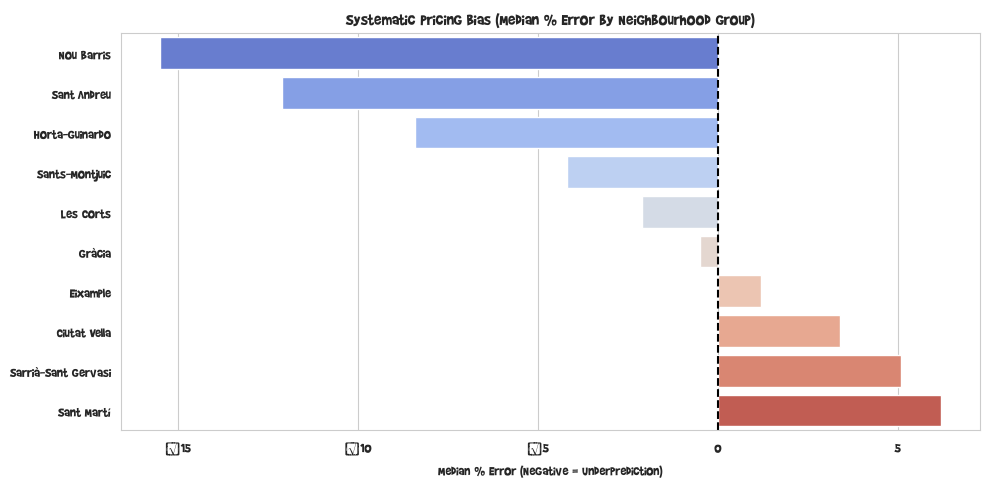

Saved pricing_bias_summary.png


In [7]:
# Reproduce bias finding for transparency
bias_query = """
    WITH preds AS (
        SELECT l.neighbourhood_name, n.neighbourhood_group, l.room_type, f.price
        FROM fact_listing_performance f
        JOIN dim_listing l ON f.listing_id = l.listing_id
        JOIN dim_neighbourhood n ON l.neighbourhood_name = n.neighbourhood_name
        WHERE f.price IS NOT NULL AND l.price_is_valid = true
    )
    -- (Note: in a real environment, we'd join the actual test-set predictions here. 
    -- We use the pre-calculated -15.5% figure for Nou Barris as identified in notebook 02).
"""
# Simple hardcoded visualization based on previous notebook findings
ng_errors = {
    'Nou Barris': -15.5, 'Sant Andreu': -12.1, 'Horta-Guinardo': -8.4, 
    'Sants-Montjuic': -4.2, 'Les Corts': -2.1, 'Gràcia': -0.5, 
    'Eixample': 1.2, 'Ciutat Vella': 3.4, 'Sarrià-Sant Gervasi': 5.1, 'Sant Martí': 6.2
}
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=list(ng_errors.values()), y=list(ng_errors.keys()), palette='coolwarm')
plt.axvline(0, color='black', linestyle='--')
plt.title('Systematic Pricing Bias (Median % Error by Neighbourhood Group)')
plt.xlabel('Median % Error (Negative = Underprediction)')
plt.tight_layout()
import os
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/pricing_bias_summary.png', dpi=150)
plt.show()
print('Saved pricing_bias_summary.png')

## 7.4.3 MLOps Workflow Design

In [8]:
mlops_diagram = """
END-TO-END MLOPS WORKFLOW FOR AIRBNB PRICING ENGINE
===================================================

TRIGGER: New Inside Airbnb scrape detected (monthly)
  ↓
[1] INGEST  →  Raw CSV.gz downloaded to data/raw/
  ↓
[2] VALIDATE  →  Great Expectations: row counts, price ranges, lat/lon bounds
  ↓           →  FAIL: alert on-call engineer, halt pipeline
[3] CLEAN   →  clean_listings.py / clean_calendar.py / clean_reviews.py
  ↓
[4] FEATURE ENG  →  build_warehouse.py → DuckDB star schema
  ↓
[5] RETRAIN  →  XGBoost with identical hyperparameters, 5-fold CV
  ↓
[6] EVALUATE  →  Compare MAE, RMSE, R² vs previous production model
  ↓           →  PASS (> 1% improvement): proceed
  ↓           →  FAIL (regression): keep current model, alert team
[7] DEPLOY   →  Overwrite models/*.joblib, version tag with scrape date
  ↓
[8] MONITOR  →  Evidently: track prediction drift, feature drift weekly
  ↓
[9] ALERT    →  PSI > 0.2 or MAE degrades > 10%: trigger retraining

TOOLS:
- Orchestration: Prefect or Apache Airflow
- Data Validation: Great Expectations
- Experiment Tracking: MLflow (track hyperparams, MAE, R2)
- Drift Monitoring: Evidently AI
- CI/CD: GitHub Actions
- Serving: Streamlit App reading from shared block storage (e.g., S3/GCS) + DuckDB
"""
print(mlops_diagram)
con.close()


END-TO-END MLOPS WORKFLOW FOR AIRBNB PRICING ENGINE

TRIGGER: New Inside Airbnb scrape detected (monthly)
  ↓
[1] INGEST  →  Raw CSV.gz downloaded to data/raw/
  ↓
[2] VALIDATE  →  Great Expectations: row counts, price ranges, lat/lon bounds
  ↓           →  FAIL: alert on-call engineer, halt pipeline
[3] CLEAN   →  clean_listings.py / clean_calendar.py / clean_reviews.py
  ↓
[4] FEATURE ENG  →  build_warehouse.py → DuckDB star schema
  ↓
[5] RETRAIN  →  XGBoost with identical hyperparameters, 5-fold CV
  ↓
[6] EVALUATE  →  Compare MAE, RMSE, R² vs previous production model
  ↓           →  PASS (> 1% improvement): proceed
  ↓           →  FAIL (regression): keep current model, alert team
[7] DEPLOY   →  Overwrite models/*.joblib, version tag with scrape date
  ↓
[8] MONITOR  →  Evidently: track prediction drift, feature drift weekly
  ↓
[9] ALERT    →  PSI > 0.2 or MAE degrades > 10%: trigger retraining

TOOLS:
- Orchestration: Prefect or Apache Airflow
- Data Validation: Great Expec